In [1]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns

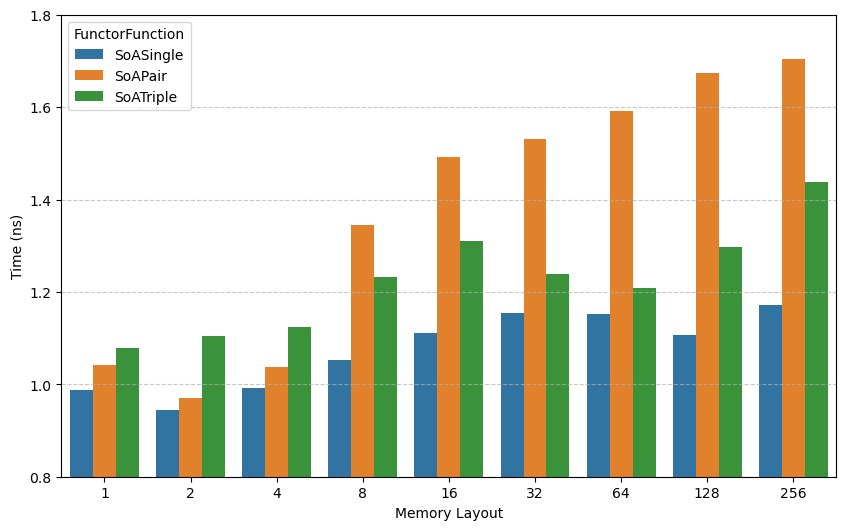

In [61]:
# 1. Load the data
with open('benchmark_results.json', 'r') as f:
    data = json.load(f)
    
with open('benchmark_ref_results.json', 'r') as f:
    data_ref = json.load(f)
    
# 2. Extract context and benchmark results
version_label = f"{data['context']['autopas_branch']} ({data['context']['autopas_commit'][:8]})"
version_label_ref = f"{data_ref['context']['autopas_branch']} ({data_ref['context']['autopas_commit'][:8]})"

df = pd.DataFrame(data_ref['benchmarks'])
df['Version'] = 'Reference'

df_ref = pd.DataFrame(data['benchmarks'])
df_ref['Version'] = 'Current'

combined_df = pd.concat([df_ref, df], ignore_index=True)
# Remove the globals version
combined_df = combined_df[~combined_df['name'].str.contains('Global', na=False)]
# Split the name into parameters
combined_df[['FunctorType', 'ParticlesPerCell', 'CellSize', 'CutOff']] = combined_df['name'].str.split('/', expand=True)
# Extract the functor function
combined_df['FunctorFunction'] = combined_df['FunctorType'].str.split('_', expand=True)[2]


# Normalize values
def normalize_column(df, col_name, reference='Reference'):
    new_col_name = col_name + '_normalized'
    keys = ['FunctorType', 'ParticlesPerCell', 'CutOff']

    # 1. Create a clean mapping of config -> baseline value
    # We filter for reference, then group to handle duplicates (averaging them)
    baseline_map = (
        df[df['Version'] == reference]
        .groupby(keys)[col_name]
        .mean()
    )

    # 2. Map the baseline values back to the main dataframe
    # We create a temporary series of keys to match against the baseline_map index
    # transform('first') ensures the value is broadcasted to every row in the group
    baselines = df.set_index(keys).index.map(baseline_map)

    # 3. Calculate Normalized and Speedup columns safely
    df[new_col_name] = df[col_name] / baselines
    df['Speedup'] = 1.0 / df[new_col_name]
    
    return df

combined_df = normalize_column(combined_df, 'real_time')

# 4. Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=combined_df.loc[~(combined_df['Version'] == 'Reference')], x='ParticlesPerCell', y='Speedup', hue='FunctorFunction')
# sns.catplot(data=combined_df, 
#             kind="bar",
#             x="ParticlesPerCell", 
#             y="Speedup", 
#             hue="Version", 
#             col="FunctorFunction")
# plt.title(f"AutoPas Functor Performance (Commit: {version_label})")
plt.ylim(0.8, 1.8)
plt.ylabel("Time (ns)")
plt.xlabel("Memory Layout")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

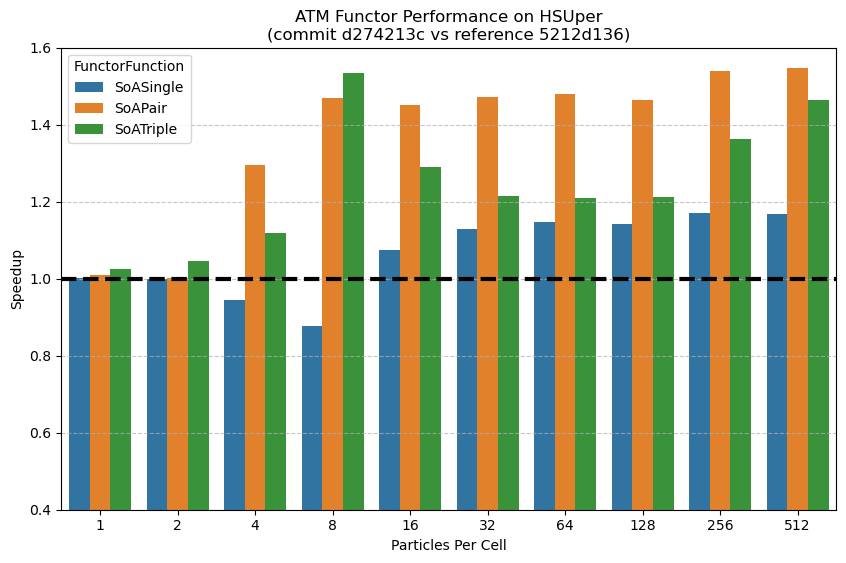

In [80]:
# 1. Load the data
with open('benchmark_results_hsuper.json', 'r') as f:
    data = json.load(f)
    
with open('benchmark_ref_results_hsuper.json', 'r') as f:
    data_ref = json.load(f)
    
# 2. Extract context and benchmark results
version_label = f"{data['context']['autopas_branch']} ({data['context']['autopas_commit'][:8]})"
version_label_ref = f"{data_ref['context']['autopas_branch']} ({data_ref['context']['autopas_commit'][:8]})"

df = pd.DataFrame(data_ref['benchmarks'])
df['Version'] = 'Reference'

df_ref = pd.DataFrame(data['benchmarks'])
df_ref['Version'] = 'Current'

combined_df = pd.concat([df_ref, df], ignore_index=True)
# Remove the globals version
combined_df = combined_df[~combined_df['name'].str.contains('Global', na=False)]
# Split the name into parameters
combined_df[['FunctorType', 'ParticlesPerCell', 'CellSize', 'CutOff']] = combined_df['name'].str.split('/', expand=True)
# Extract the functor function
combined_df['FunctorFunction'] = combined_df['FunctorType'].str.split('_', expand=True)[2]
# Remove AoS Results
combined_df = combined_df[~combined_df['name'].str.contains('AoS', na=False)]

# Normalize values
def normalize_column(df, col_name, reference='Reference'):
    new_col_name = col_name + '_normalized'
    keys = ['FunctorType', 'ParticlesPerCell', 'CutOff']

    # 1. Create a clean mapping of config -> baseline value
    # We filter for reference, then group to handle duplicates (averaging them)
    baseline_map = (
        df[df['Version'] == reference]
        .groupby(keys)[col_name]
        .mean()
    )

    # 2. Map the baseline values back to the main dataframe
    # We create a temporary series of keys to match against the baseline_map index
    # transform('first') ensures the value is broadcasted to every row in the group
    baselines = df.set_index(keys).index.map(baseline_map)

    # 3. Calculate Normalized and Speedup columns safely
    df[new_col_name] = df[col_name] / baselines
    df['Speedup'] = 1.0 / df[new_col_name]
    
    return df

combined_df = normalize_column(combined_df, 'real_time')

# 4. Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=combined_df.loc[~(combined_df['Version'] == 'Reference')], x='ParticlesPerCell', y='Speedup', hue='FunctorFunction')
plt.axhline(1.0, linestyle='--', color='black', linewidth=3)
# sns.catplot(data=combined_df, 
#             kind="bar",
#             x="ParticlesPerCell", 
#             y="Speedup", 
#             hue="Version", 
#             col="FunctorFunction")
plt.title(f"ATM Functor Performance on HSUper\n(commit {data['context']['autopas_commit'][:8]} vs reference {data_ref['context']['autopas_commit'][:8]})")
plt.ylim(0.4, 1.6)
plt.ylabel("Speedup")
plt.xlabel("Particles Per Cell")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()